## 3.Data cleaning ##

In [ ]:


# -------------------------------------------------
# STEP 1: Import Libraries
# -------------------------------------------------
import pandas as pd
import numpy as np

# -------------------------------------------------
# STEP 2: Load Dataset
# -------------------------------------------------
data = pd.read_csv(r"C:\YouTube_Social_Media_Anlytics_Project\data\raw\youtube_data.csv")

print("Original Dataset")
print(data.head())

# -------------------------------------------------
# STEP 3: Remove Duplicate Rows
# -------------------------------------------------
data = data.drop_duplicates()

# -------------------------------------------------
# STEP 4: Remove Missing Values
# -------------------------------------------------
data = data.dropna()

# -------------------------------------------------
# STEP 5: Convert Date Format
# -------------------------------------------------
data['published_at'] = pd.to_datetime(data['published_at'])

# -------------------------------------------------
# STEP 6: Reset Index
# -------------------------------------------------
data = data.reset_index(drop=True)

print("Cleaned Dataset")
print(data.head())



## 4.Exploratory Data Analysis (EDA) ##

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
channel_count = data['channel'].value_counts()

print("Videos per Channel")
print(channel_count)
channel_count.plot(kind='bar')

# -------------------------------------------------
# GRAPH 1: Videos per Channel
# -------------------------------------------------
plt.figure(figsize=(8,4))

data['channel'].value_counts().plot(kind='bar')

plt.title("Number of Videos per Channel")
plt.xlabel("Channel")
plt.ylabel("Video Count")

plt.show()

# -------------------------------------------------
# GRAPH 2: Videos Published per Year
# -------------------------------------------------
data['published_at'] = pd.to_datetime(data['published_at'])

data['year'] = data['published_at'].dt.year

sns.countplot(x='year', data=data)

plt.title("Videos Published Each Year")
plt.show()

# -------------------------------------------------
# GRAPH 3: Channel Distribution Pie Chart
# -------------------------------------------------
data['channel'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title("Channel Distribution")
plt.show()


## 5.Content-Based Social Media Analysis (Topic Analysis) ##

Dataset Preview:
      video_id                                              title  \
0  65CASowfnKs  AI Tutorial for Beginners 2026: How To Use AI ...   
1  Yq0QkCxoTHM  Google’s AI Course for Beginners (in 10 minutes)!   
2  0Tch0N5nsRU  You’re not behind (yet): How to learn AI in 18...   
3  9c7zh2MkslY  You’re Not Behind (Yet): How to Learn AI in 29...   
4  yHk7Vavmc7Q  AI Tools EXPLAINED:  How to Use Them? (2025 Gu...   

         channel          published_at  
0  Mikey No Code  2026-03-11T14:05:19Z  
1        Jeff Su  2023-11-14T13:00:33Z  
2    Dan Martell  2026-03-05T14:00:01Z  
3    Futurepedia  2025-07-31T18:50:11Z  
4      AI Master  2024-12-12T14:01:02Z  

Discovered Topics:

Topic 1:
['mo', 'beginners', 'make', 'scratch', 'course', 'python', 'tutorial', 'minutes', 'learn', 'ai']

Topic 2:
['app', 'google', 'tools', 'beginners', 'use', 'n8n', '2026', 'tutorial', 'build', 'ai']

Topic 3:
['agents', 'guide', 'explained', '2025', 'tutorial', 'intelligence', 'artificial', 'co

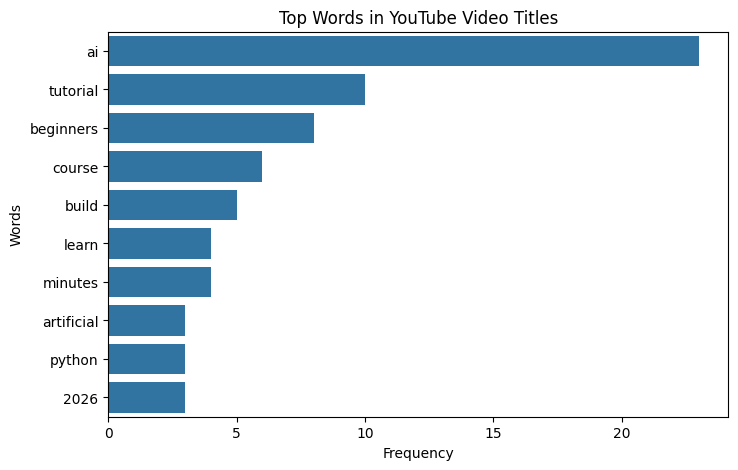

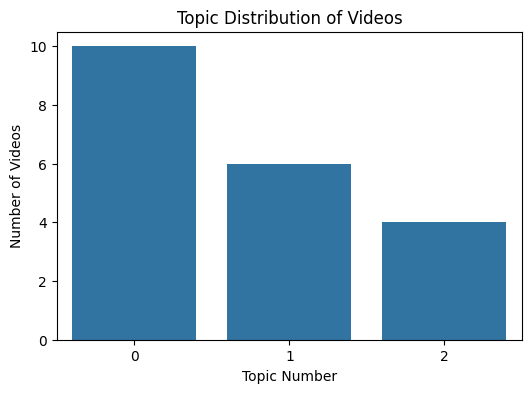

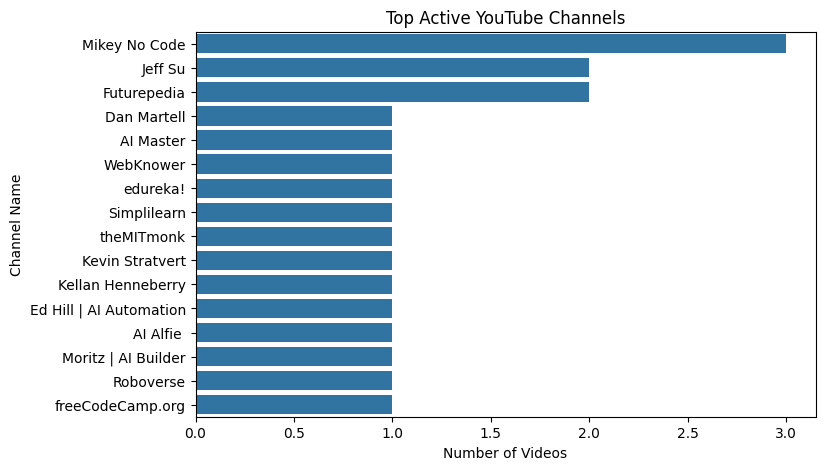

In [6]:
# ===============================
# STEP 1: Import Libraries
# ===============================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation


# ===============================
# STEP 2: Load Dataset
# ===============================
data = pd.read_csv(r"C:\YouTube_Social_Media_Anlytics_Project\data\raw\youtube_data.csv")

print("Dataset Preview:")
print(data.head())


# ===============================
# STEP 3: Text Vectorization
# ===============================
vectorizer = CountVectorizer(stop_words='english')

X = vectorizer.fit_transform(data['title'])


# ===============================
# STEP 4: Topic Modeling (LDA)
# ===============================
lda = LatentDirichletAllocation(n_components=3, random_state=42)

lda.fit(X)


# ===============================
# STEP 5: Display Topics
# ===============================
words = vectorizer.get_feature_names_out()

print("\nDiscovered Topics:\n")

for i, topic in enumerate(lda.components_):
    
    print(f"Topic {i+1}:")
    
    topic_words = [words[j] for j in topic.argsort()[-10:]]
    
    print(topic_words)
    
    print()


# ===============================
# VISUALIZATION 1
# Top Words in Titles
# ===============================
word_freq = pd.DataFrame({
    
    'word': vectorizer.get_feature_names_out(),
    
    'count': X.toarray().sum(axis=0)
})

top_words = word_freq.sort_values(by='count', ascending=False).head(10)

plt.figure(figsize=(8,5))

sns.barplot(x='count', y='word', data=top_words)

plt.title("Top Words in YouTube Video Titles")

plt.xlabel("Frequency")

plt.ylabel("Words")

plt.show()


# ===============================
# VISUALIZATION 2
# Topic Distribution
# ===============================
topic_results = lda.transform(X)

data['topic'] = topic_results.argmax(axis=1)

plt.figure(figsize=(6,4))

sns.countplot(x='topic', data=data)

plt.title("Topic Distribution of Videos")

plt.xlabel("Topic Number")

plt.ylabel("Number of Videos")

plt.show()


# ===============================
# VISUALIZATION 3
# Channel vs Number of Videos
# ===============================
channel_counts = data['channel'].value_counts()

plt.figure(figsize=(8,5))

sns.barplot(x=channel_counts.values, y=channel_counts.index)

plt.title("Top Active YouTube Channels")

plt.xlabel("Number of Videos")

plt.ylabel("Channel Name")

plt.show()

## 6.Structure Based Analysis (Network) ##

Dataset Preview:
      video_id                                              title  \
0  65CASowfnKs  AI Tutorial for Beginners 2026: How To Use AI ...   
1  Yq0QkCxoTHM  Google’s AI Course for Beginners (in 10 minutes)!   
2  0Tch0N5nsRU  You’re not behind (yet): How to learn AI in 18...   
3  9c7zh2MkslY  You’re Not Behind (Yet): How to Learn AI in 29...   
4  yHk7Vavmc7Q  AI Tools EXPLAINED:  How to Use Them? (2025 Gu...   

         channel          published_at  
0  Mikey No Code  2026-03-11T14:05:19Z  
1        Jeff Su  2023-11-14T13:00:33Z  
2    Dan Martell  2026-03-05T14:00:01Z  
3    Futurepedia  2025-07-31T18:50:11Z  
4      AI Master  2024-12-12T14:01:02Z  


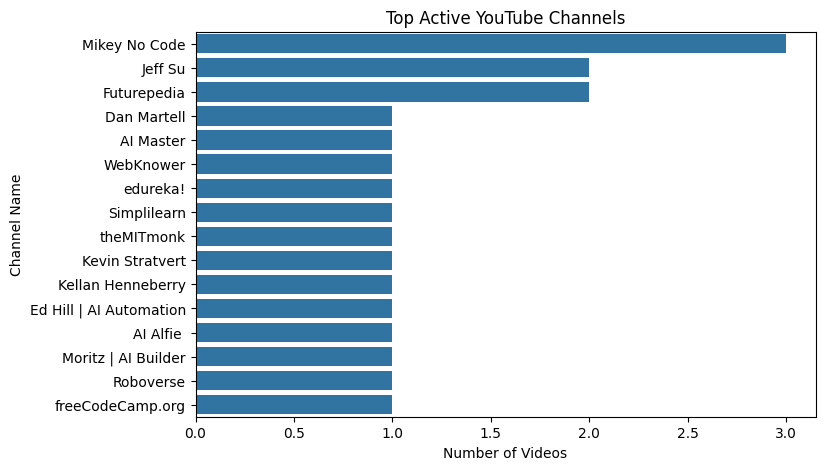

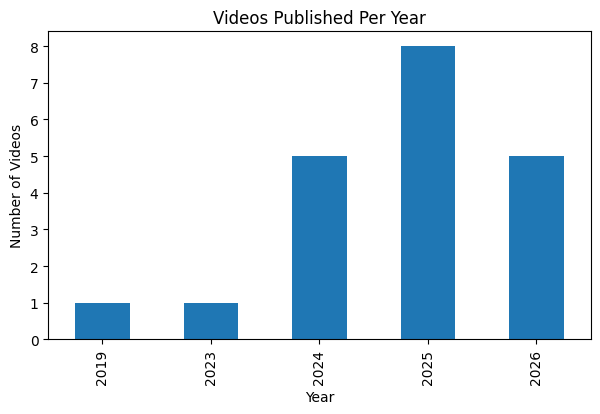

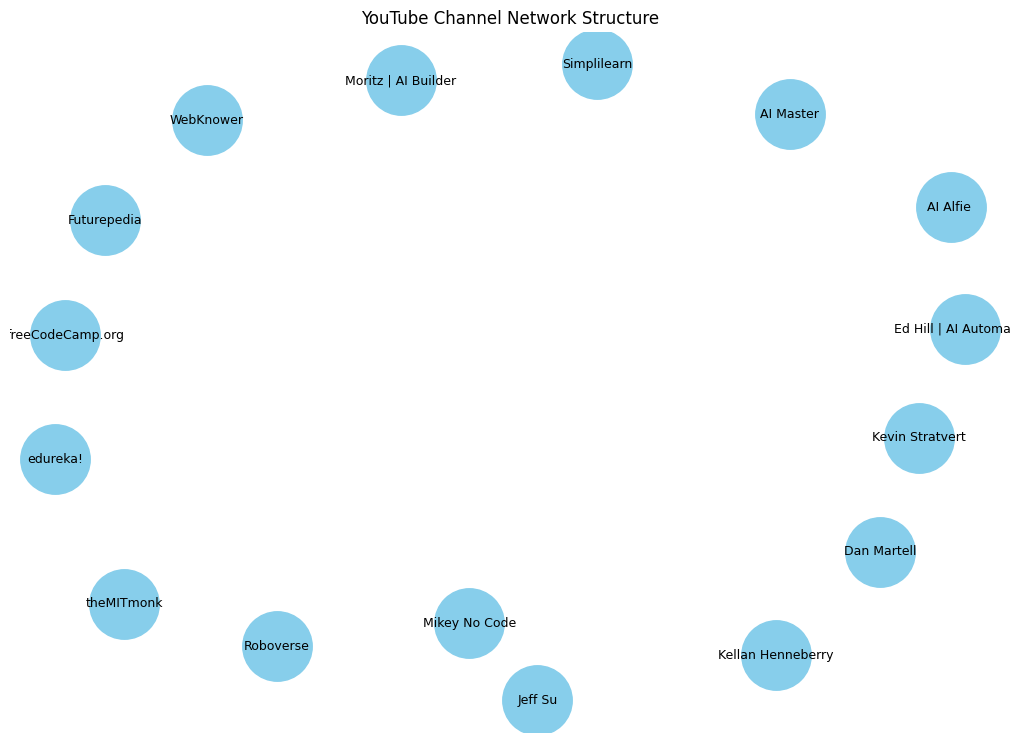

In [7]:
# =========================================
# STEP 1: Import Libraries
# =========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx


# =========================================
# STEP 2: Load Dataset
# =========================================

data = pd.read_csv(r"C:\YouTube_Social_Media_Anlytics_Project\data\raw\youtube_data.csv")

print("Dataset Preview:")
print(data.head())


# =========================================
# STEP 3: Channel Activity Analysis
# =========================================

channel_counts = data['channel'].value_counts()

plt.figure(figsize=(8,5))

sns.barplot(x=channel_counts.values, y=channel_counts.index)

plt.title("Top Active YouTube Channels")

plt.xlabel("Number of Videos")

plt.ylabel("Channel Name")

plt.show()


# =========================================
# STEP 4: Publishing Structure Analysis
# =========================================

data['published_at'] = pd.to_datetime(data['published_at'])

data['year'] = data['published_at'].dt.year

year_counts = data['year'].value_counts().sort_index()

plt.figure(figsize=(7,4))

year_counts.plot(kind='bar')

plt.title("Videos Published Per Year")

plt.xlabel("Year")

plt.ylabel("Number of Videos")

plt.show()


# =========================================
# STEP 5: Social Media Network Graph
# =========================================

G = nx.Graph()

channels = data['channel'].unique()

for channel in channels:
    
    G.add_node(channel)

plt.figure(figsize=(10,7))

nx.draw(G,
        with_labels=True,
        node_size=2500,
        node_color="skyblue",
        font_size=9)

plt.title("YouTube Channel Network Structure")

plt.show()

## 7.Dashboard using Streamlit ##

## 8.Creative Campaign Design for Social Media Promotion ##

In [10]:
# ------------------------------------------------------------
# PRACTICAL 8 : CREATIVE CAMPAIGN DESIGN FOR SOCIAL MEDIA
# ------------------------------------------------------------

import pandas as pd
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer


# ------------------------------------------------------------
# Load Dataset
# ------------------------------------------------------------

data = pd.read_csv(r"C:\YouTube_Social_Media_Anlytics_Project\data\raw\youtube_data.csv")

print("Total Records:", len(data))


# ------------------------------------------------------------
# Extract Keywords from Video Titles
# ------------------------------------------------------------

vectorizer = CountVectorizer(stop_words='english')

X = vectorizer.fit_transform(data['title'])

word_freq = X.toarray().sum(axis=0)

words = vectorizer.get_feature_names_out()

word_counts = dict(zip(words, word_freq))

top_keywords = sorted(word_counts, key=word_counts.get, reverse=True)[:5]


print("\nTop Keywords Driving Discussion:")
print(top_keywords)


# ------------------------------------------------------------
# Generate Campaign Name
# ------------------------------------------------------------

campaign_name = f"AI {top_keywords[0].capitalize()} Revolution 2026"

print("\nCampaign Name:")
print(campaign_name)


# ------------------------------------------------------------
# Instagram Content
# ------------------------------------------------------------

instagram_caption = f"""
Explore the future of AI with exciting new {top_keywords[0]} tutorials.
Learn powerful {top_keywords[1]} techniques,
discover advanced {top_keywords[2]} tools,
and stay ahead in the AI revolution.
"""

# ------------------------------------------------------------
# Twitter Content
# ------------------------------------------------------------

twitter_post = f"""
AI is transforming the future.
Learn {top_keywords[0]}, discover {top_keywords[1]},
and build powerful solutions with AI.

#AI #MachineLearning #Technology
"""


# ------------------------------------------------------------
# LinkedIn Content
# ------------------------------------------------------------

linkedin_post = f"""
Artificial Intelligence is shaping the future of innovation.

Our campaign focuses on learning {top_keywords[0]},
improving knowledge in {top_keywords[1]},
and exploring modern {top_keywords[2]} technologies.

Join the AI transformation journey.
"""


print("\nInstagram Caption:\n", instagram_caption)

print("\nTwitter Post:\n", twitter_post)

print("\nLinkedIn Post:\n", linkedin_post)


# ------------------------------------------------------------
# Target Audience
# ------------------------------------------------------------

target_audience = "Students, AI enthusiasts, developers, and tech learners."

print("\nTarget Audience:")
print(target_audience)


# ------------------------------------------------------------
# KPI Recommendations
# ------------------------------------------------------------

kpis = [
"Increase Social Media Engagement by 30%",
"Grow AI Learning Community",
"Increase Video Watch Time",
"Boost AI Content Reach"
]

print("\nCampaign KPI Recommendations:")

for k in kpis:
    print("-", k)


# ------------------------------------------------------------
# Hashtag Strategy
# ------------------------------------------------------------

hashtags = f"#AI #{top_keywords[0].capitalize()} #{top_keywords[1].capitalize()} #MachineLearning #Tech"

print("\nHashtag Strategy:")
print(hashtags)

Total Records: 20

Top Keywords Driving Discussion:
['ai', 'tutorial', 'beginners', 'course', 'build']

Campaign Name:
AI Ai Revolution 2026

Instagram Caption:
 
Explore the future of AI with exciting new ai tutorials.
Learn powerful tutorial techniques,
discover advanced beginners tools,
and stay ahead in the AI revolution.


Twitter Post:
 
AI is transforming the future.
Learn ai, discover tutorial,
and build powerful solutions with AI.

#AI #MachineLearning #Technology


LinkedIn Post:
 
Artificial Intelligence is shaping the future of innovation.

Our campaign focuses on learning ai,
improving knowledge in tutorial,
and exploring modern beginners technologies.

Join the AI transformation journey.


Target Audience:
Students, AI enthusiasts, developers, and tech learners.

Campaign KPI Recommendations:
- Increase Social Media Engagement by 30%
- Grow AI Learning Community
- Increase Video Watch Time
- Boost AI Content Reach

Hashtag Strategy:
#AI #Ai #Tutorial #MachineLearning #Tec

## 9: Competitor Activity Analysis ##

Dataset Preview:

      video_id                                              title  \
0  65CASowfnKs  AI Tutorial for Beginners 2026: How To Use AI ...   
1  Yq0QkCxoTHM  Google’s AI Course for Beginners (in 10 minutes)!   
2  0Tch0N5nsRU  You’re not behind (yet): How to learn AI in 18...   
3  9c7zh2MkslY  You’re Not Behind (Yet): How to Learn AI in 29...   
4  yHk7Vavmc7Q  AI Tools EXPLAINED:  How to Use Them? (2025 Gu...   

         channel          published_at  
0  Mikey No Code  2026-03-11T14:05:19Z  
1        Jeff Su  2023-11-14T13:00:33Z  
2    Dan Martell  2026-03-05T14:00:01Z  
3    Futurepedia  2025-07-31T18:50:11Z  
4      AI Master  2024-12-12T14:01:02Z  

Total Records: 20


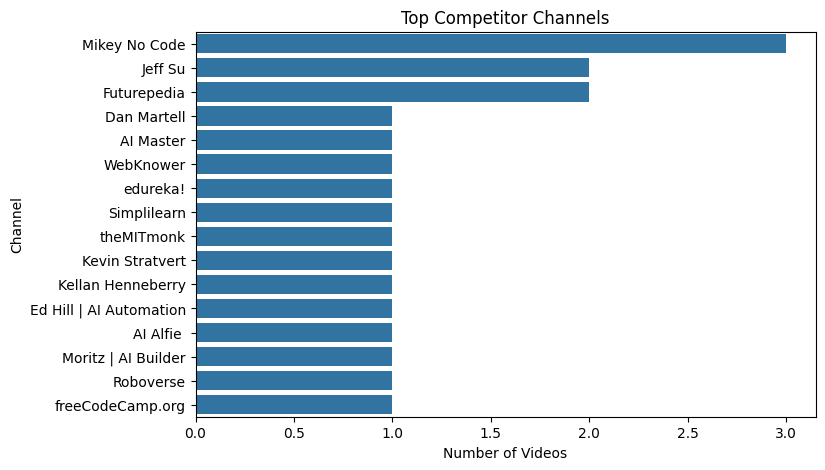

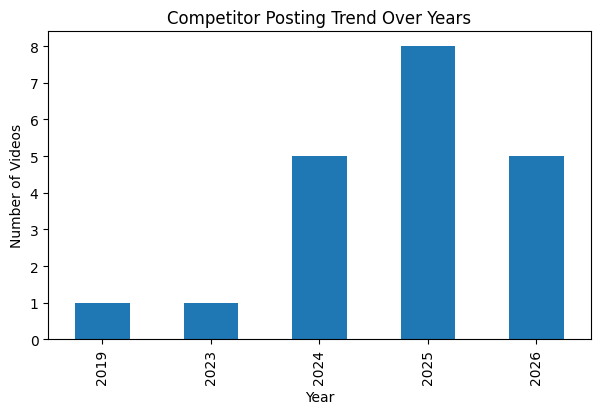

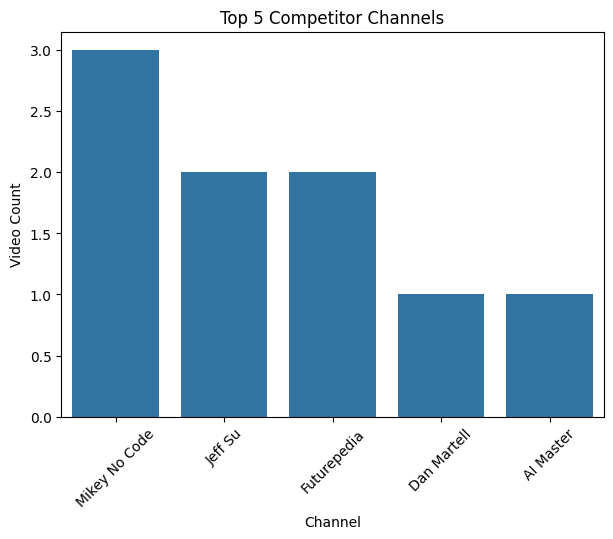

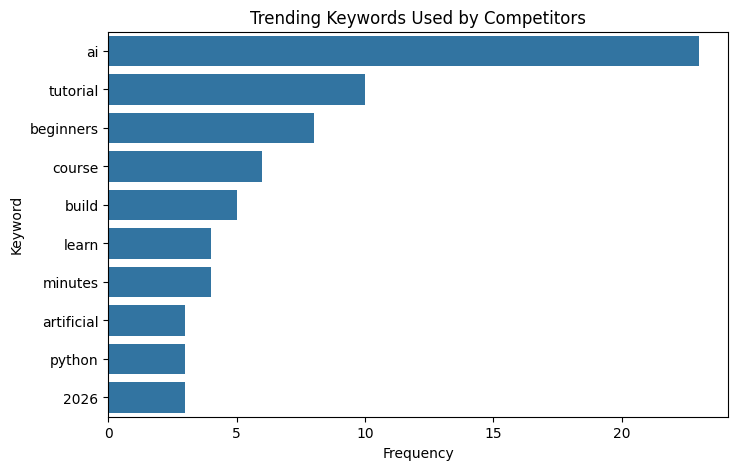


Competitor Insights:
- Most active competitor: Mikey No Code
- Total competitors analyzed: 16
- Most trending keyword: ai


In [11]:
# =========================================================
# PRACTICAL 9 : COMPETITOR ACTIVITY ANALYSIS
# =========================================================

# Step 1: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer


# Step 2: Load Dataset
data = pd.read_csv(r"C:\YouTube_Social_Media_Anlytics_Project\data\raw\youtube_data.csv")

print("Dataset Preview:\n")
print(data.head())

print("\nTotal Records:", len(data))


# Step 3: Convert Date
data['published_at'] = pd.to_datetime(data['published_at'])

data['year'] = data['published_at'].dt.year


# =========================================================
# Visualization 1: Top Competitor Channels
# =========================================================

channel_counts = data['channel'].value_counts()

plt.figure(figsize=(8,5))

sns.barplot(x=channel_counts.values, y=channel_counts.index)

plt.title("Top Competitor Channels")

plt.xlabel("Number of Videos")

plt.ylabel("Channel")

plt.show()


# =========================================================
# Visualization 2: Competitor Posting Trend
# =========================================================

year_counts = data['year'].value_counts().sort_index()

plt.figure(figsize=(7,4))

year_counts.plot(kind='bar')

plt.title("Competitor Posting Trend Over Years")

plt.xlabel("Year")

plt.ylabel("Number of Videos")

plt.show()


# =========================================================
# Visualization 3: Top 5 Competitors
# =========================================================

top5 = data['channel'].value_counts().head(5)

plt.figure(figsize=(7,5))

sns.barplot(x=top5.index, y=top5.values)

plt.title("Top 5 Competitor Channels")

plt.xlabel("Channel")

plt.ylabel("Video Count")

plt.xticks(rotation=45)

plt.show()


# =========================================================
# Visualization 4: Trending Keywords Used by Competitors
# =========================================================

vectorizer = CountVectorizer(stop_words='english')

X = vectorizer.fit_transform(data['title'])

word_freq = pd.DataFrame({
    'word': vectorizer.get_feature_names_out(),
    'count': X.toarray().sum(axis=0)
})

top_words = word_freq.sort_values(by='count', ascending=False).head(10)

plt.figure(figsize=(8,5))

sns.barplot(x='count', y='word', data=top_words)

plt.title("Trending Keywords Used by Competitors")

plt.xlabel("Frequency")

plt.ylabel("Keyword")

plt.show()


# =========================================================
# Competitor Insights
# =========================================================

print("\nCompetitor Insights:")

print("- Most active competitor:", data['channel'].value_counts().idxmax())

print("- Total competitors analyzed:", data['channel'].nunique())

print("- Most trending keyword:", top_words.iloc[0]['word'])

## 10: Social Media Text Analytics Model (Customer Review Analysis) ##

Dataset Preview:

      video_id                                              title  \
0  65CASowfnKs  AI Tutorial for Beginners 2026: How To Use AI ...   
1  Yq0QkCxoTHM  Google’s AI Course for Beginners (in 10 minutes)!   
2  0Tch0N5nsRU  You’re not behind (yet): How to learn AI in 18...   
3  9c7zh2MkslY  You’re Not Behind (Yet): How to Learn AI in 29...   
4  yHk7Vavmc7Q  AI Tools EXPLAINED:  How to Use Them? (2025 Gu...   

         channel          published_at  
0  Mikey No Code  2026-03-11T14:05:19Z  
1        Jeff Su  2023-11-14T13:00:33Z  
2    Dan Martell  2026-03-05T14:00:01Z  
3    Futurepedia  2025-07-31T18:50:11Z  
4      AI Master  2024-12-12T14:01:02Z  

Total Records: 20

Sentiment Distribution:
sentiment
Neutral     10
Positive     8
Negative     2
Name: count, dtype: int64


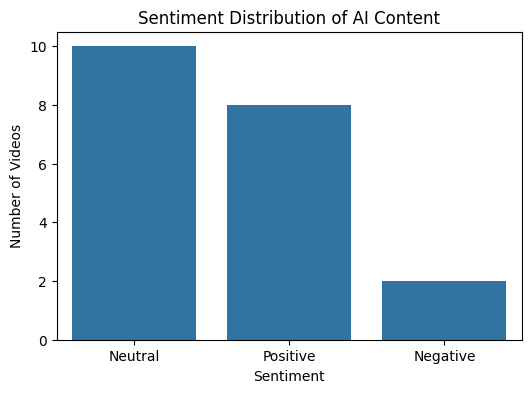

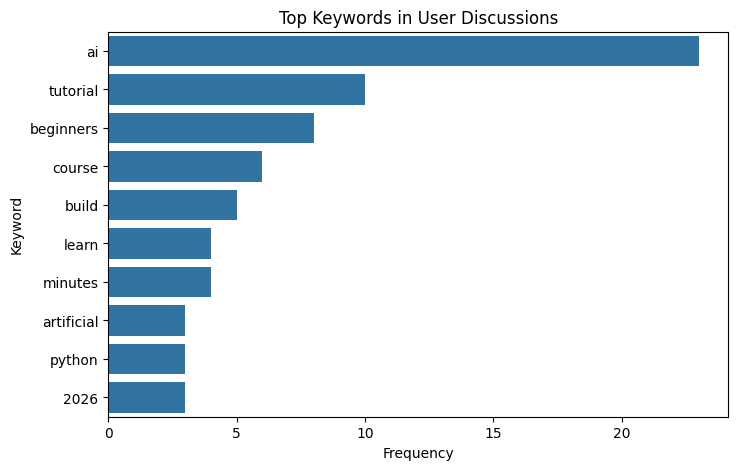

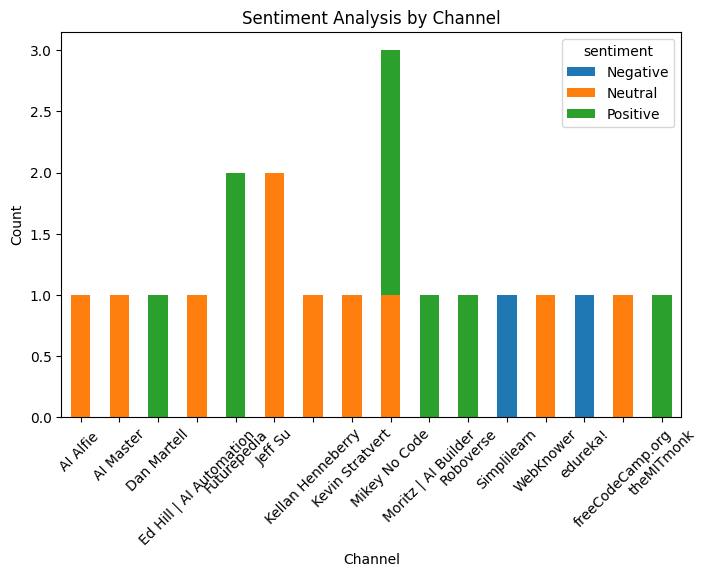

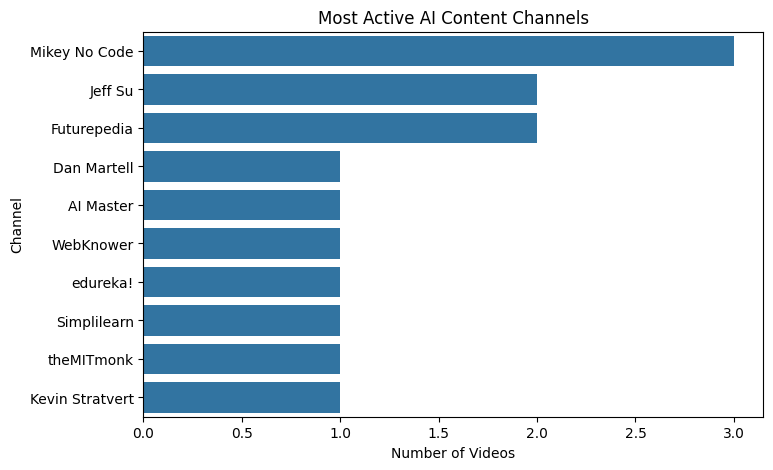


Text Analytics Insights:
- Most active channel: Mikey No Code
- Total channels analyzed: 16
- Most discussed keyword: ai


In [12]:
# =========================================================
# PRACTICAL 10 : SOCIAL MEDIA TEXT ANALYTICS MODEL
# Customer Review / Opinion Analysis
# =========================================================

# Step 1: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer


# Step 2: Load Dataset
data = pd.read_csv(r"C:\YouTube_Social_Media_Anlytics_Project\data\raw\youtube_data.csv")

print("Dataset Preview:\n")
print(data.head())

print("\nTotal Records:", len(data))


# =========================================================
# Step 3: Sentiment Analysis
# =========================================================

def get_sentiment(text):
    
    analysis = TextBlob(str(text))
    
    if analysis.sentiment.polarity > 0:
        return "Positive"
    
    elif analysis.sentiment.polarity < 0:
        return "Negative"
    
    else:
        return "Neutral"


data['sentiment'] = data['title'].apply(get_sentiment)

print("\nSentiment Distribution:")
print(data['sentiment'].value_counts())


# =========================================================
# Visualization 1: Sentiment Distribution
# =========================================================

plt.figure(figsize=(6,4))

sns.countplot(x='sentiment', data=data)

plt.title("Sentiment Distribution of AI Content")

plt.xlabel("Sentiment")

plt.ylabel("Number of Videos")

plt.show()


# =========================================================
# Visualization 2: Top Words in Customer Reviews
# =========================================================

vectorizer = CountVectorizer(stop_words='english')

X = vectorizer.fit_transform(data['title'])

word_freq = pd.DataFrame({
    'word': vectorizer.get_feature_names_out(),
    'count': X.toarray().sum(axis=0)
})

top_words = word_freq.sort_values(by='count', ascending=False).head(10)

plt.figure(figsize=(8,5))

sns.barplot(x='count', y='word', data=top_words)

plt.title("Top Keywords in User Discussions")

plt.xlabel("Frequency")

plt.ylabel("Keyword")

plt.show()


# =========================================================
# Visualization 3: Sentiment by Channel
# =========================================================

sentiment_channel = pd.crosstab(data['channel'], data['sentiment'])

sentiment_channel.plot(kind='bar', stacked=True, figsize=(8,5))

plt.title("Sentiment Analysis by Channel")

plt.xlabel("Channel")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()


# =========================================================
# Visualization 4: Most Active Channels
# =========================================================

channel_counts = data['channel'].value_counts().head(10)

plt.figure(figsize=(8,5))

sns.barplot(x=channel_counts.values, y=channel_counts.index)

plt.title("Most Active AI Content Channels")

plt.xlabel("Number of Videos")

plt.ylabel("Channel")

plt.show()


# =========================================================
# Text Analytics Insights
# =========================================================

print("\nText Analytics Insights:")

print("- Most active channel:", data['channel'].value_counts().idxmax())

print("- Total channels analyzed:", data['channel'].nunique())

print("- Most discussed keyword:", top_words.iloc[0]['word'])